# Basic usage of PHYSBO

## Introduction

In this tutorial, we will learn how to use PHYSBO to solve a optimization problem.

First, we import modules.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import physbo

The problem we will solve is to find the minimum value of the one-dimensional function $f(x) = 3 x^4 + 4 x ^3 + 1.0$.
The exact solution is $x=-1.0$.

In [2]:
def fn(x):
    return 3 * x**4 + 4 * x**3 + 1.0

## Defining the search space

Define the search space for the function to be optimized.
In PHYSBO, you need to prepare the candidate points to be searched in advance as a `np.ndarray`.
The array shape should be `(N, d)`, where `N` is the number of candidate points and `d` is the dimensionality of the search space.
If you want to divide each dimension into equally spaced intervals, you can conveniently use `physbo.search.utility.make_grid`.
In the example below, the search space `X` is defined by splitting the interval from `x_min = -2.0` to `x_max = 2.0` into `window_num=10001` evenly spaced grid points.

In [3]:
window_num=10001
x_max = [2.0]
x_min = [-2.0]

X = physbo.search.utility.make_grid(x_min, x_max, window_num)

## Definition of the simulator

In PHYSBO, the function (or `Callable` object) that actually computes the objective function is called the `simulator`.

The `simulator` receives an index or indices (`action`) of candidate points to evaluate and returns the value(s) of the objective function at those points.
Typically, to allow evaluation of multiple points at once, `action` is expected to be a `np.ndarray` of indices.

**Since PHYSBO always tries to maximize the objective function**, for minimization problems like this example,
we simply return the negative value of the function to turn it into a maximization problem.

You can easily create such a `simulator` using `physbo.search.utility.Simulator`, which wraps your function and candidate points to meet these requirements.

In [4]:
simulator = physbo.search.utility.Simulator(X, fn, negate=True)

## Performing optimization

### Setting policy

First, set the optimization `Policy`.  

Next, set `test_X` to the matrix of search candidates (`numpy.array`).

In [5]:
# set policy 
policy = physbo.search.discrete.Policy(test_X=X)

# set seed
policy.set_seed(0)

When `policy` is set, no optimization is done yet.
Execute the following methods on `policy` to optimize it.

- `random_search`.  
- `bayes_search`.

If you specify the `simulator` and the number of search steps in these methods, the following loop will be executed for the number of search steps.

i) Select the next parameter to be executed from the candidate parameters.

ii) Execute `simulator` with the selected parameters.

The default number of parameter returned by i) is one, but it is possible to return multiple parameters in one step.
See the section "Searching for multiple candidates at once" for details.  

Also, instead of running the above loop inside PHYSBO, it is possible to control i) and ii) separately from the outside. In other words, it is possible to propose the next parameter to be executed from PHYSBO, evaluate its objective function value in some way outside PHYSBO (e.g., by experiment rather than numerical calculation), propose it in some way outside PHYSBO, and register the evaluated value in PHYSBO. For more details, please refer to the "Running Interactively" section of the tutorial.

### Random Search

First of all, let's perform a random search.

Since Bayesian optimization requires at least two objective function values to be obtained (the initial number of data required depends on the problem to be optimized and the dimension d of the parameters), we will first perform a random search.   

**argument**.  

- `max_num_probes`: Number of search steps.  
- `simulator`: The simulator of the objective function (an object of class simulator). 

In [6]:
res = policy.random_search(max_num_probes=20, simulator=simulator)

0001-th step: f(x) = -51.387604 (action=9395)
   current best f(x) = -51.387604 (best action=9395) 

0002-th step: f(x) = -0.581263 (action=3583)
   current best f(x) = -0.581263 (best action=3583) 

0003-th step: f(x) = -0.827643 (action=4015)
   current best f(x) = -0.581263 (best action=3583) 

0004-th step: f(x) = -14.220707 (action=154)
   current best f(x) = -0.581263 (best action=3583) 

0005-th step: f(x) = -34.192764 (action=8908)
   current best f(x) = -0.581263 (best action=3583) 

0006-th step: f(x) = -31.595527 (action=8819)
   current best f(x) = -0.581263 (best action=3583) 

0007-th step: f(x) = -0.361729 (action=3269)
   current best f(x) = -0.361729 (best action=3269) 

0008-th step: f(x) = -0.755839 (action=3870)
   current best f(x) = -0.361729 (best action=3269) 

0009-th step: f(x) = -10.883996 (action=370)
   current best f(x) = -0.361729 (best action=3269) 

0010-th step: f(x) = -0.150313 (action=2949)
   current best f(x) = -0.150313 (best action=2949) 

0011-t

When executed, the objective function value and its action ID for each step, and the best value up to now and its action ID will be printed as follows.

````
0020-th step: f(x) = -19.075990 (action=8288)
   current best f(x) = -0.150313 (best action=2949) 
````

These output can be suppressed by setting `is_disp=False` in the argument.

### Bayesian Optimization

Next, we run the Bayesian optimization as follows.

**argument**.

- `max_num_probes`: Number of search steps.
- `simulator`: The simulator of the objective function (an object of class simulator).
- `score`: The type of acquisition function. You can specify one of the following
    - TS (Thompson Sampling)
    - EI (Expected Improvement)
    - PI (Probability of Improvement)
- `interval`:
The hyperparameters are trained at the specified interval.
If a negative value is specified, no hyperparameter will be learned.
0 means that hyperparameter learning will be performed only in the first step.
- `num_rand_basis`: Number of basis functions. 0 means that a normal Gaussian process without Bayesian linear model will be used.

In [7]:
res = policy.bayes_search(
    max_num_probes=50,
    simulator=simulator,
    score="TS",
    interval=0,
    num_rand_basis=500,
    is_disp=False,
)

## Checking the results

The search result ``res`` is returned as an object of the ``history`` class (`physbo.search.discrete.results.history`).  
The following is a reference to the search results.

- `res.fx` : The history of evaluated values of simulator (objective function).
- `res.chosen_actions`: The history of action IDs (parameters) when the simulator was evaluated.  
- `fbest, best_action= res.export_all_sequence_best_fx()`: The history of best values and their action IDs (parameters) for all timings when the simulator was evaluated.
- `res.total_num_search`: Total number of simulator evaluations.

Let's plot the objective function value and the best value at each step.  
`res.fx` and `best_fx` should range up to `res.total_num_search`, respectively.

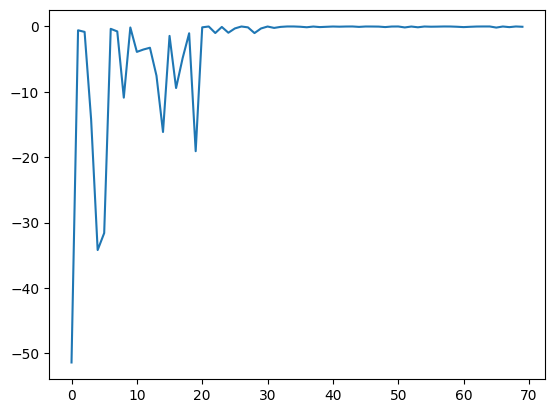

In [8]:
plt.plot(res.fx[0:res.total_num_search])

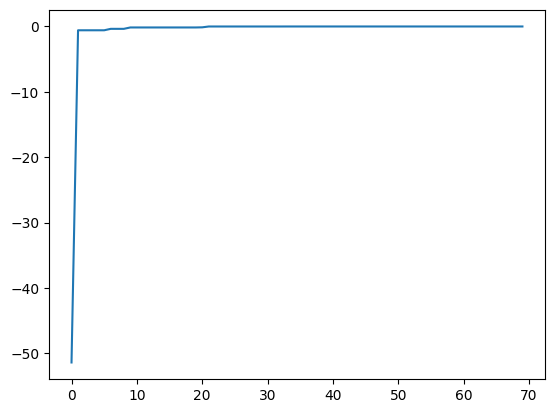

In [9]:
best_fx, best_action = res.export_all_sequence_best_fx()
plt.plot(best_fx)

## Serializing the results

The search results can be saved to an external file using the `save` method.

In [10]:
res.save('search_result.npz')

In [11]:
del res

Load the saved result file as follows:

In [12]:
res = physbo.search.discrete.History()
res.load('search_result.npz')

Finally, the candidate with the best score can be displayed as follows. You can see that we have arrived at the correct solution $x=-1$.

In [13]:
print(X[int(best_action[-1])])

[-1.002]


## Prediction

`policy` serves `get_post_fmean` and `get_post_fcov` methods for calculating mean value and variance of Gaussian process (post distribution). 

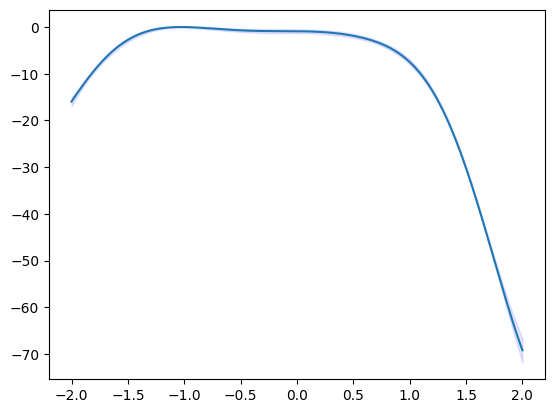

In [14]:
mean = policy.get_post_fmean(X)
var = policy.get_post_fcov(X)
std = np.sqrt(var)
xs = X[:,0]

ax = plt.subplot()
ax.plot(xs, mean)
ax.fill_between(xs, mean-std, mean+std, color="blue", alpha=.1)

## Acquisition function

`policy` serves `get_score` method for calculating acquisition function.

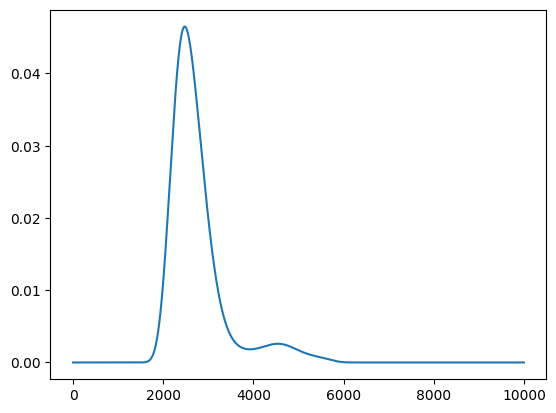

In [15]:
scores = policy.get_score(mode="EI", xs=X)
plt.plot(scores)

## Parallelization

PHYSBO can calculate acquisition functions for candidates in parallel by using MPI via `mpi4py` .
To enable MPI parallelization, pass a MPI communicator such as `MPI.COMM_WORLD` to a keyword argument, `comm` of the constructor of the `policy`.

In [16]:
# from mpi4py import MPI
# policy = physbo.search.discrete.policy(test_X=X, comm=MPI.COMM_WORLD)